In [1]:
import torch
import numpy as np

## "PINN" to approximate quadratic function

In [2]:
class PINN(torch.nn.Module):
    def __init__(self, size=128):
        super(PINN, self).__init__()
        self.fc1 = torch.nn.Linear(1, size)
        self.fc2 = torch.nn.Linear(size, size)
        self.out = torch.nn.Linear(size, 1)
        self.relu = torch.nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.out(x)
        return x

In [3]:
model = PINN()
model.forward(torch.tensor([1], dtype=torch.float32))

tensor([0.1166], grad_fn=<ViewBackward0>)

In [4]:
# device = torch.device("mps")
# model.to(device)

# commented because using device introduces some problems

In [ ]:
# Sample random data between 0 and 1
N = 10000
X_np = np.random.random(N).reshape(-1, 1)
X = torch.tensor(X_np, dtype=torch.float32)

# Y is quadratic function
Y_np = np.array([X_np[i]**2 for i in range(len(X))]).reshape(-1, 1)
Y = torch.tensor(Y_np, dtype=torch.float32)

In [6]:
X.shape

torch.Size([1000, 1])

In [7]:
Y.shape

torch.Size([1000, 1])

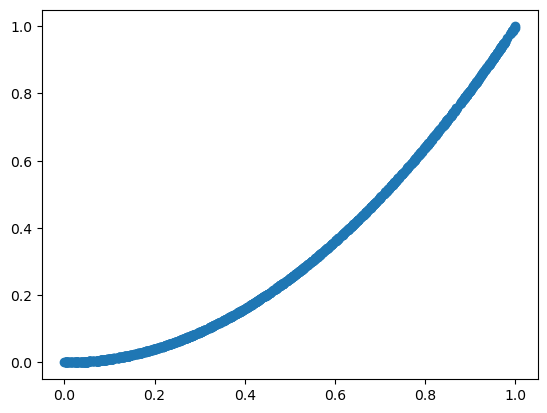

In [8]:
# plot Y

import matplotlib.pyplot as plt

plt.scatter(X_np, Y_np)
plt.show()

/var/folders/0p/3b6s1cyd2glf9kj66m2vt2gm0000gn/T/ipykernel_39826/874305818.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  initial_guess = torch.tensor(model.forward(X[:100])).cpu().detach()


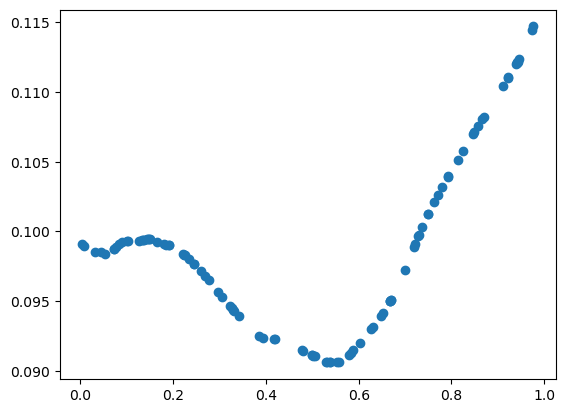

In [9]:
# model with initialized random weights

initial_guess = torch.tensor(model.forward(X[:100])).cpu().detach()

plt.scatter(X_np[:100], initial_guess)
plt.show()

In [ ]:
# Training Loop

BATCH = 500
EPOCHS = 20

loss_hist = []

loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.01)

for epoch in range(EPOCHS):
    train_batch = X[(epoch*BATCH):(epoch*BATCH)+BATCH]
    target_batch = Y[(epoch*BATCH):(epoch*BATCH)+BATCH]
    out = model.forward(train_batch)
    optimizer.zero_grad()
    loss = loss_fn(out, target_batch)
    loss_hist.append(loss)
    loss.backward()
    optimizer.step()
    print(f"Epoch {epoch}, loss {loss}")
    
    

Epoch 0, loss 0.13313136994838715
Epoch 1, loss 0.941153883934021
Epoch 2, loss 0.04046578332781792
Epoch 3, loss 0.30119094252586365
Epoch 4, loss 0.33751675486564636
Epoch 5, loss 0.26005494594573975
Epoch 6, loss 0.09799604117870331
Epoch 7, loss 0.02171400748193264
Epoch 8, loss 0.02844914048910141
Epoch 9, loss 0.05855783075094223
Epoch 10, loss 0.08703040331602097
Epoch 11, loss 0.09213510155677795
Epoch 12, loss 0.07391858100891113
Epoch 13, loss 0.04358787462115288
Epoch 14, loss 0.024928178638219833
Epoch 15, loss 0.01907290518283844
Epoch 16, loss 0.015458272770047188
Epoch 17, loss 0.01770707406103611
Epoch 18, loss 0.02667025849223137
Epoch 19, loss 0.024505961686372757


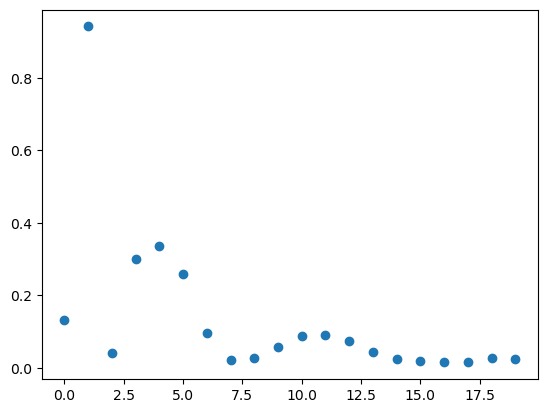

In [12]:
loss_hist = torch.tensor(loss_hist).detach()
plt.scatter([i for i in range(20)], loss_hist)
plt.show()

In [13]:
results = model(Y[0:100])
results_cpu = results.cpu().detach().numpy()

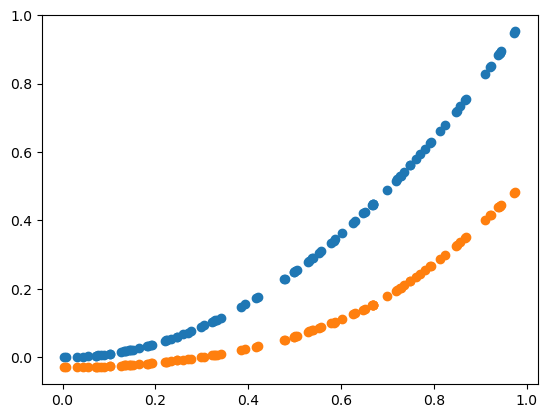

In [14]:
plt.scatter(X[0:100], Y[0:100])
plt.scatter(X[0:100], results_cpu)
plt.show()
